We are going to do the same thing for the same dataset, but this time with CNN.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import datasets
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPool2D
from tensorflow.keras.utils import to_categorical

In [2]:
test_data = pd.read_csv("D:\\python-venv\\NN\\data\\fashion-mnist_test.csv")
train_data = pd.read_csv("D:\\python-venv\\NN\\data\\fashion-mnist_train.csv")
test_data = test_data.values
train_data = train_data.values

In [3]:
fashion_mnist = np.concatenate((train_data , test_data) ,  axis=0)

In [4]:
X = fashion_mnist[:, 1:]
y = fashion_mnist[:, 0]

In [5]:
X=X.reshape(-1,28,28)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train , X_test , y_train ,  y_test = train_test_split(X,y , test_size=0.1)

In [8]:
class_name = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

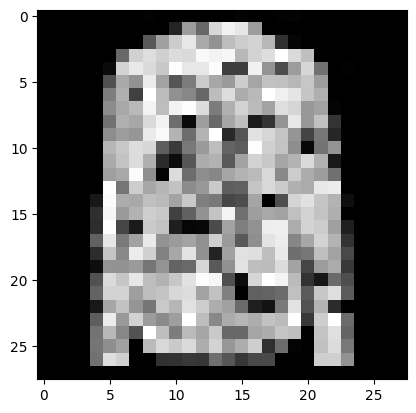

Shirt


In [9]:
index=1
plt.imshow(X_train[index],cmap='gray')
plt.show()
print(class_name[y_train[index]])

In [10]:
y_test = to_categorical(y_test)
y_train = to_categorical(y_train)

Normalizing

In [12]:
X_train = X_train / 255
X_test = X_test / 255

In [13]:
X_train.shape

(63000, 28, 28)

In [14]:
X_test.shape

(7000, 28, 28)

In [15]:
y_train.shape

(63000, 10)

In [16]:
y_test.shape

(7000, 10)

In [19]:
model = keras.models.Sequential()
model.add(Conv2D(filters=8,kernel_size= (3,3) , padding='same' , input_shape=(28,28,1) , activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=16,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(Conv2D(filters=16,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=32,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(Conv2D(filters=32,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPool2D())
model.add(Conv2D(filters=64,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(Conv2D(filters=64,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPool2D())
model.add(Conv2D(filters=128,kernel_size= (3,3) , padding='same' ,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=256 , activation='relu' ))
model.add(Dropout(0.4))
model.add(Dense(units=256 , activation='relu' ))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(units=10 , activation='softmax'))

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1, 1, 256)      │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1, 1, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,122 (969.23 KB)

 Trainable params: 248,122 (969.23 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
opt = tf.optimizers.Adam(learning_rate=0.000275)
loss = tf.losses.CategoricalCrossentropy()

model.compile(optimizer=opt , loss= loss , metrics= [tf.metrics.CategoricalAccuracy()])

In [19]:
history = model.fit(X_train, y_train, epochs=40, batch_size=100, validation_split=0.2, verbose=2)

Epoch 1/40
504/504 - 32s - 64ms/step - categorical_accuracy: 0.5058 - loss: 1.2208 - val_categorical_accuracy: 0.7421 - val_loss: 0.7736
Epoch 2/40
504/504 - 39s - 77ms/step - categorical_accuracy: 0.7407 - loss: 0.6963 - val_categorical_accuracy: 0.7807 - val_loss: 0.5944
Epoch 3/40
504/504 - 39s - 78ms/step - categorical_accuracy: 0.7773 - loss: 0.5950 - val_categorical_accuracy: 0.8098 - val_loss: 0.5134
Epoch 4/40
504/504 - 47s - 93ms/step - categorical_accuracy: 0.7992 - loss: 0.5294 - val_categorical_accuracy: 0.8301 - val_loss: 0.4616
Epoch 5/40
504/504 - 26s - 52ms/step - categorical_accuracy: 0.8167 - loss: 0.4893 - val_categorical_accuracy: 0.8367 - val_loss: 0.4643
Epoch 6/40
504/504 - 39s - 77ms/step - categorical_accuracy: 0.8315 - loss: 0.4544 - val_categorical_accuracy: 0.8567 - val_loss: 0.4113
Epoch 7/40
504/504 - 35s - 70ms/step - categorical_accuracy: 0.8464 - loss: 0.4235 - val_categorical_accuracy: 0.8744 - val_loss: 0.3702
Epoch 8/40
504/504 - 29s - 57ms/step - ca

In [21]:
model.evaluate(X_test , y_test)

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - categorical_accuracy: 0.9177 - loss: 0.2213


[0.22134897112846375, 0.9177142977714539]

In [22]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

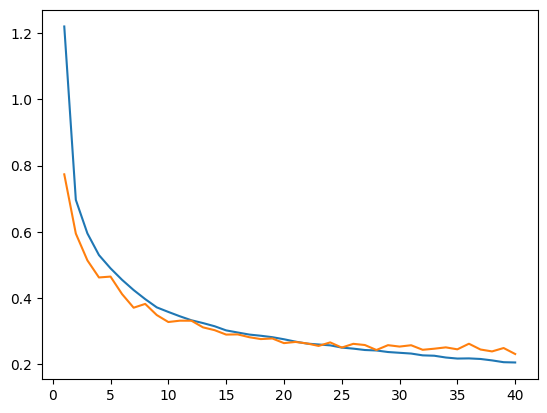

In [23]:
plt.plot(epochs , loss)
plt.plot(epochs , val_loss)